            temp  co2  ff_emission
year                              
2020  288.390086  NaN     9.608939
2021  288.535859  NaN     9.616843
2022  288.592529  NaN     9.554982
2023  288.497677  NaN     9.520338
2024  288.505908  NaN     9.515465
2025  288.640852  NaN     9.499651
2026  288.320037  NaN     9.472820
2027  288.337158  NaN     9.571891
2028  288.554806  NaN     9.507876
2029  288.779087  NaN    10.105426
2030         NaN  NaN    10.749322
2031         NaN  NaN    11.414986
2032         NaN  NaN    12.056806
2033         NaN  NaN    12.684307
2034         NaN  NaN    12.630690
Columns: ['temp', 'co2', 'ff_emission']


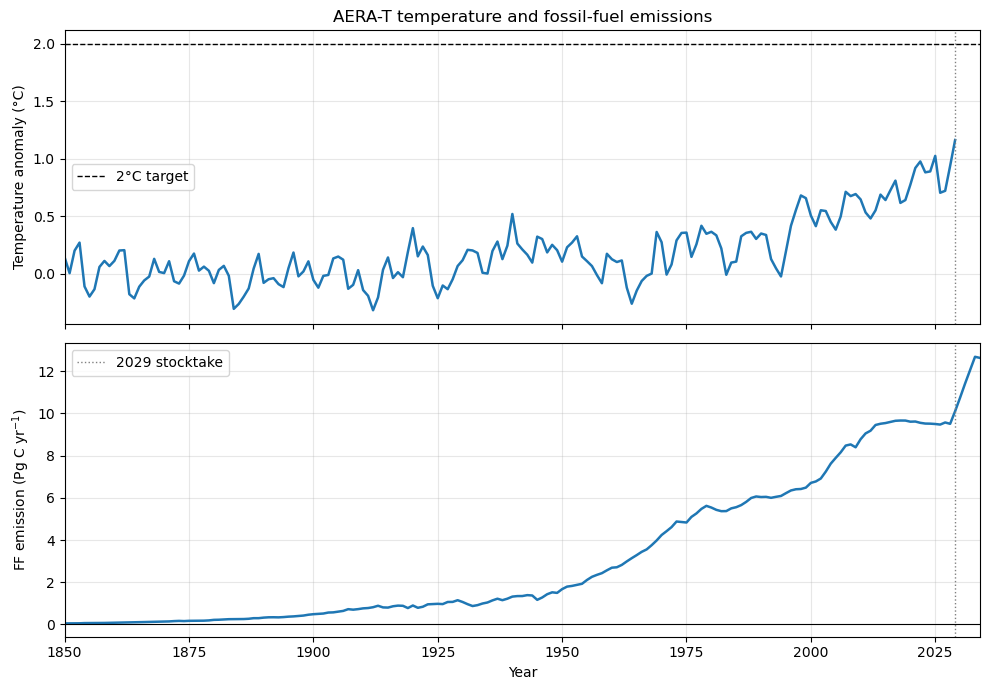

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CSV = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    "AERA_future/AERA_T_Betzy/AERA_T_Betzy_state_2029.csv"
)

df = pd.read_csv(CSV, index_col=0)
df.index = df.index.astype(int)
df.index.name = "year"

print(df.tail(15))
print("Columns:", df.columns.tolist())

# AERA state CSV column names
tas = df["temp"].dropna()
ff = df["ff_emission"].dropna()

# Temperature anomaly relative to 1850–1900
tas_ref = tas.loc[1850:1900].mean()
tas_anom = tas - tas_ref

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(tas_anom.index, tas_anom, lw=1.8)
axes[0].axhline(2.0, color="k", ls="--", lw=1, label="2°C target")
axes[0].axvline(2029, color="0.5", ls=":", lw=1)
axes[0].set_ylabel("Temperature anomaly (°C)")
axes[0].set_title("AERA-T temperature and fossil-fuel emissions")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ff.index, ff, lw=1.8)
axes[1].axvline(2029, color="0.5", ls=":", lw=1, label="2029 stocktake")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("FF emission (Pg C yr$^{-1}$)")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[1].set_xlim(1850, 2034)

plt.tight_layout()
plt.show()

In [2]:
import pickle
import numpy as np

PKL = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    "AERA_future/AERA_T_Betzy/AERA_T_Betzy_ann_tas_co2_ems_2029.dat"
)

with open(PKL, "rb") as f:
    field = pickle.load(f)

for i, x in enumerate(field):
    x = np.asarray(x)
    print(i, x.shape, x[:3], "...", x[-3:])

0 (185,) [1850. 1851. 1852.] ... [2032. 2033. 2034.]
1 (185,) [287.75834969 287.62051479 287.81658122] ... [nan nan nan]
2 (185,) [nan nan nan] ... [nan nan nan]
3 (185,) [0.05126757 0.05144734 0.05352353] ... [12.05680555 12.68430659 12.63068981]


In [5]:
from pathlib import Path
import aera

df_base = aera.get_base_df()

print("AERA package:", aera.__file__)
print(df_base.loc[2020:2034, [
    "ff_emission",
    "lu_emission",
    "non_co2_emission",
]])

Use the following non-CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/data/nonco2_emis_ssp126_v3.dat
Use the following land use emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/data/lu_emis_ssp126_bern3d_adj_GCB2020_v1.dat
Use the following historical fossil fuel CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/data/co2_ff_GCP_plus_NDC_v1.dat
AERA package: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/__init__.py
      ff_emission  lu_emission  non_co2_emission
year                                            
2020        9.279     0.830900          2.835012
2021        9.419     0.737733          2.883852
2022        9.498     0.713015          2.932825
2023        9.545     0.659776          2.981931
2024        9.597     0.616045          2.990604
2025        9.635     0.579919         

Use the following non-CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/data/nonco2_emis_ssp126_v3.dat
Use the following land use emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/data/lu_emis_ssp126_bern3d_adj_GCB2020_v1.dat
Use the following historical fossil fuel CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_master_260702/AERA/aera/data/co2_ff_GCP_plus_NDC_v1.dat


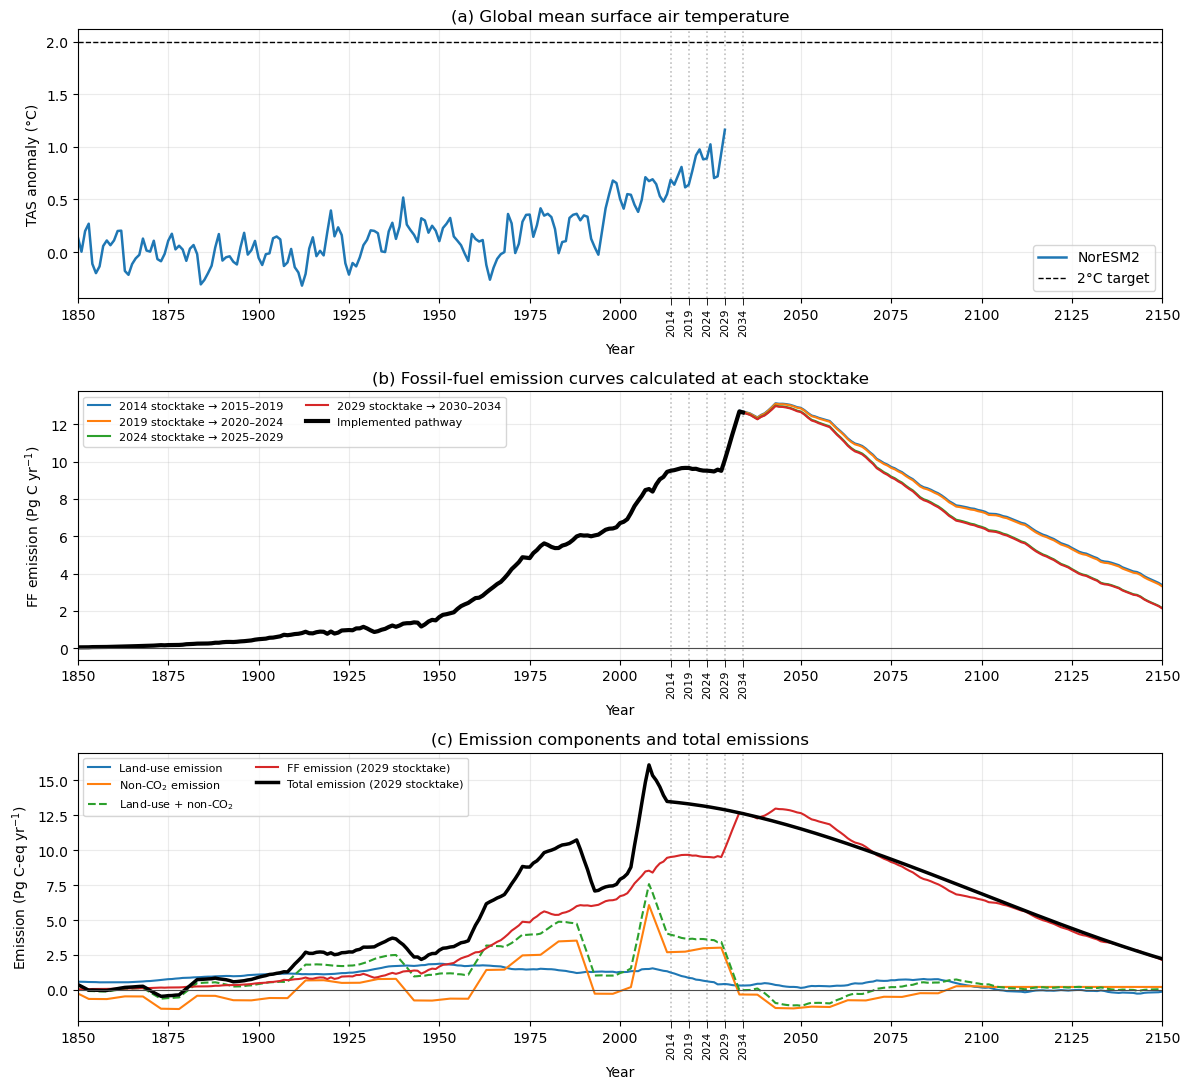

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import aera

# ============================================================
# Files
# ============================================================

STATE_FILE = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    "AERA_future/AERA_T_Betzy/AERA_T_Betzy_state_2029.csv"
)

CURVE_FILES = {
    "2014 stocktake → 2015–2019": (
        "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
        "AERA_hist/AERA_T_Betzy/AERA_T_hist_nird_2014.csv"
    ),
    "2019 stocktake → 2020–2024": (
        "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
        "AERA_future/AERA_T_Betzy/AERA_T_Betzy_2019.csv"
    ),
    "2024 stocktake → 2025–2029": (
        "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
        "AERA_future/AERA_T_Betzy/AERA_T_Betzy_2024.csv"
    ),
    "2029 stocktake → 2030–2034": (
        "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
        "AERA_future/AERA_T_Betzy/AERA_T_Betzy_2029.csv"
    ),
}

CURVE_END = 2150


# ============================================================
# Readers
# ============================================================

def read_year_csv(path):
    df = pd.read_csv(path)

    year_col = "year" if "year" in df.columns else df.columns[0]
    df = df.rename(columns={year_col: "year"})
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

    return df.dropna(subset=["year"]).set_index("year").sort_index()


def read_ff_curve(path):
    df = read_year_csv(path)

    if "ff_emission" in df.columns:
        col = "ff_emission"
    else:
        # Series.to_csv() 결과에서 값 column 이름이 없거나 달라도 대응
        numeric_cols = [
            c for c in df.columns
            if pd.api.types.is_numeric_dtype(df[c])
        ]
        col = numeric_cols[0]

    return pd.to_numeric(df[col], errors="coerce").dropna()


# ============================================================
# Load data
# ============================================================

state = read_year_csv(STATE_FILE)

tas_col = next(
    c for c in ["temp", "tas", "TAS"]
    if c in state.columns
)

tas = state[tas_col].dropna()
tas_anom = tas - tas.loc[1850:1900].mean()

ff_realized = state["ff_emission"].dropna()

ff_curves = {
    label: read_ff_curve(path)
    for label, path in CURVE_FILES.items()
}

# Prescribed land-use and non-CO2 emissions used by AERA
df_base = aera.get_base_df()

lu = df_base["lu_emission"].dropna()
nonco2 = df_base["non_co2_emission"].dropna()
nonff_total = lu + nonco2


# 2029 stocktake에서 계산된 전체 미래 FF emission curve
ff_2029_curve = ff_curves[
    "2029 stocktake → 2030–2034"
].rename("ff_emission")

# 과거에는 실제 적용된 emission,
# 2030년 이후에는 2029 stocktake에서 계산된 미래 곡선 사용
ff_2029 = pd.concat(
    [
        ff_realized.loc[ff_realized.index <= 2029],
        ff_2029_curve.loc[ff_2029_curve.index >= 2030],
    ]
).sort_index()

ff_2029.name = "ff_emission"

# 2029 stocktake FF curve + prescribed LU + non-CO2
emission_2029 = pd.concat(
    [
        ff_2029,
        lu.rename("lu_emission"),
        nonco2.rename("non_co2_emission"),
    ],
    axis=1,
)

emission_2029["total_emission"] = emission_2029[
    ["ff_emission", "lu_emission", "non_co2_emission"]
].sum(axis=1, min_count=3)

total_emission_2029 = emission_2029["total_emission"].dropna()

# ============================================================
# Plot settings
# ============================================================

PLOT_START = 1850
PLOT_END = 2150
STOCKTAKE_YEARS = [2014, 2019, 2024, 2029, 2034]

MAJOR_TICKS = [
    year for year in range(PLOT_START, PLOT_END + 1, 25)
    if year != 2025
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 11),
    sharex=True,
)


def format_time_axis(ax):
    """Apply common time axis and stocktake indicators."""

    ax.set_xlim(PLOT_START, PLOT_END)

    # Regular year ticks
    ax.set_xticks(MAJOR_TICKS)

    # Stocktake years as minor ticks
    ax.set_xticks(STOCKTAKE_YEARS, minor=True)
    ax.set_xticklabels(
        [str(y) for y in STOCKTAKE_YEARS],
        minor=True,
        rotation=90,
        fontsize=8,
    )

    # Major and stocktake grids
    ax.grid(which="major", alpha=0.25)
    ax.grid(
        axis="x",
        which="minor",
        linestyle=":",
        linewidth=1.2,
        alpha=0.8,
    )

    # Because sharex=True normally hides upper-panel labels
    ax.tick_params(
        axis="x",
        which="major",
        labelbottom=True,
    )
    ax.tick_params(
        axis="x",
        which="minor",
        labelbottom=True,
        length=5,
        pad=2,
    )

    ax.set_xlabel("Year")


# ============================================================
# Panel 1: TAS
# ============================================================

ax = axes[0]

ax.plot(
    tas_anom.index,
    tas_anom,
    lw=1.8,
    label="NorESM2",
)

ax.axhline(
    2.0,
    color="k",
    linestyle="--",
    linewidth=1,
    label="2°C target",
)

ax.set_ylabel("TAS anomaly (°C)")
ax.set_title("(a) Global mean surface air temperature")
ax.legend()

format_time_axis(ax)


# ============================================================
# Panel 2: FF emission curves at each stocktake
# ============================================================

ax = axes[1]

for label, curve in ff_curves.items():
    curve_plot = curve.loc[
        (curve.index >= PLOT_START)
        & (curve.index <= PLOT_END)
    ]

    ax.plot(
        curve_plot.index,
        curve_plot,
        lw=1.5,
        label=label,
    )

# Emissions actually selected and applied to the model
ff_realized_plot = ff_realized.loc[
    (ff_realized.index >= PLOT_START)
    & (ff_realized.index <= PLOT_END)
]

ax.plot(
    ff_realized_plot.index,
    ff_realized_plot,
    color="k",
    lw=3,
    label="Implemented pathway",
)

ax.axhline(0, color="0.3", lw=0.8)

ax.set_ylabel("FF emission (Pg C yr$^{-1}$)")
ax.set_title("(b) Fossil-fuel emission curves calculated at each stocktake")
ax.legend(fontsize=8, ncol=2)

format_time_axis(ax)


# ============================================================
# Panel 3: emission components and total emission
# ============================================================

ax = axes[2]

ax.plot(
    lu.index,
    lu,
    lw=1.5,
    label="Land-use emission",
)

ax.plot(
    nonco2.index,
    nonco2,
    lw=1.5,
    label="Non-CO$_2$ emission",
)

ax.plot(
    nonff_total.index,
    nonff_total,
    lw=1.5,
    linestyle="--",
    label="Land-use + non-CO$_2$",
)

# 2029 stocktake에서 계산된 FF pathway
ax.plot(
    ff_2029.index,
    ff_2029,
    lw=1.5,
    label="FF emission (2029 stocktake)",
)

# 2029 stocktake 기준 total emission
ax.plot(
    total_emission_2029.index,
    total_emission_2029,
    color="k",
    lw=2.5,
    label="Total emission (2029 stocktake)",
)

ax.axhline(0, color="0.3", lw=0.8)

ax.set_ylabel("Emission (Pg C-eq yr$^{-1}$)")
ax.set_title("(c) Emission components and total emissions")
ax.legend(fontsize=8, ncol=2)

format_time_axis(ax)


plt.tight_layout()
plt.show()

Use the following non-CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_v2.0/AERA/aera_oa/data/nonco2_emis_ssp126_v3.dat
Use the following land use emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_v2.0/AERA/aera_oa/data/lu_emis_ssp126_bern3d_adj_GCB2020_v1.dat
Use the following historical fossil fuel CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_v2.0/AERA/aera_oa/data/co2_ff_GCP_plus_NDC_v1.dat


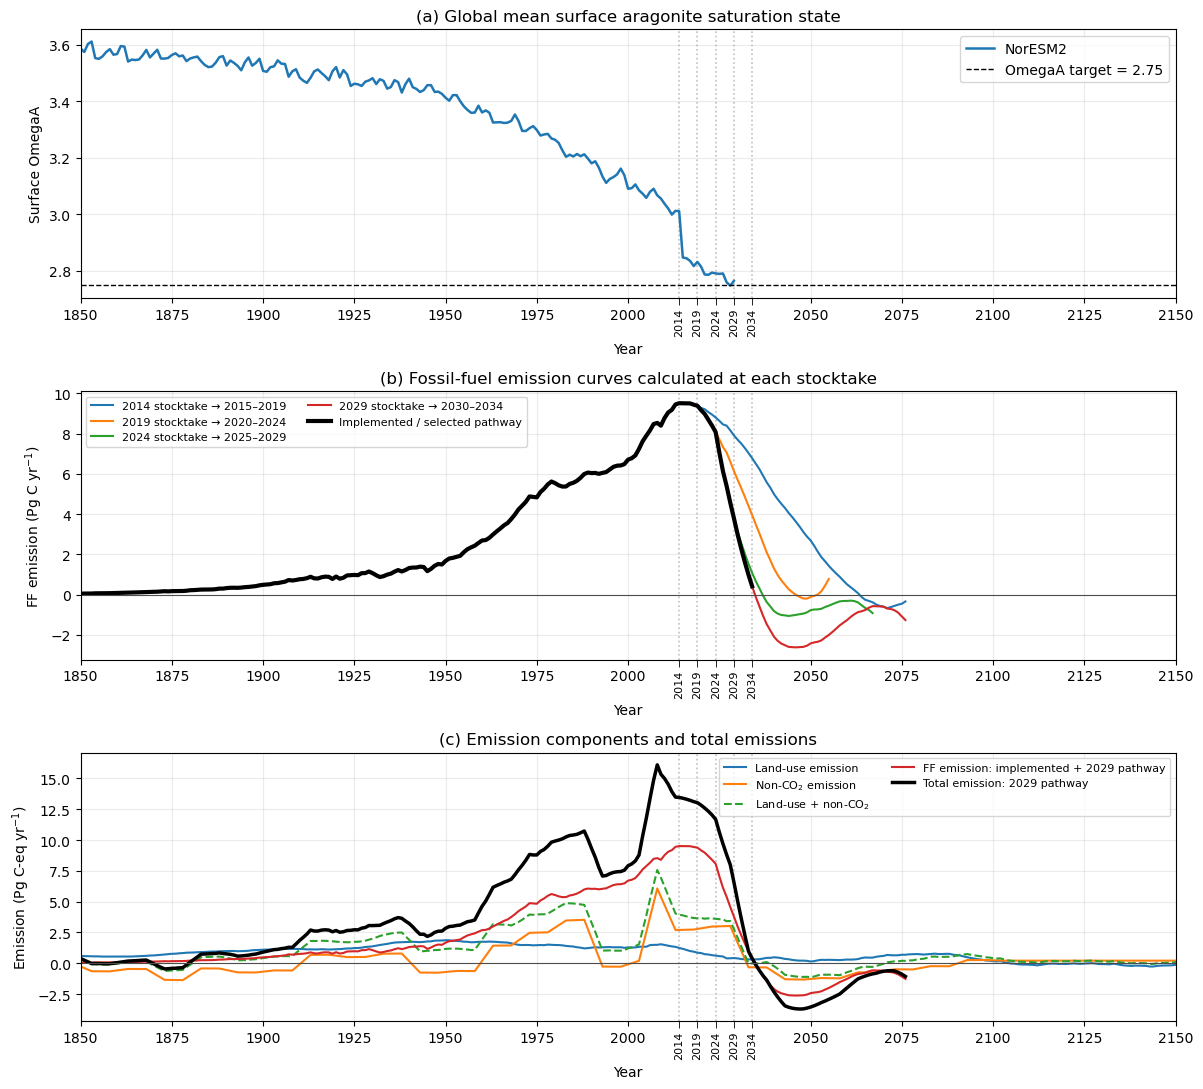

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import aera_oa

# ============================================================
# Files
# ============================================================

HIST_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    "AERA_hist/AERA_OmegaA_Betzy"
)

FUTURE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    "AERA_future/AERA_OmegaA_Betzy"
)

STATE_FILE = f"{FUTURE_DIR}/AERA_OmegaA_Betzy_state_2029.csv"

CURVE_FILES = {
    "2014 stocktake → 2015–2019": (
        f"{HIST_DIR}/AERA_OmegaA_hist_nird_2014.csv"
    ),
    "2019 stocktake → 2020–2024": (
        f"{FUTURE_DIR}/AERA_OmegaA_Betzy_2019.csv"
    ),
    "2024 stocktake → 2025–2029": (
        f"{FUTURE_DIR}/AERA_OmegaA_Betzy_2024.csv"
    ),
    "2029 stocktake → 2030–2034": (
        f"{FUTURE_DIR}/AERA_OmegaA_Betzy_2029.csv"
    ),
}

OMEGAA_TARGET = 2.75


# ============================================================
# Readers
# ============================================================

def read_year_csv(path):
    df = pd.read_csv(path)

    year_col = "year" if "year" in df.columns else df.columns[0]
    df = df.rename(columns={year_col: "year"})
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

    return (
        df.dropna(subset=["year"])
        .assign(year=lambda x: x["year"].astype(int))
        .set_index("year")
        .sort_index()
    )


def read_ff_curve(path):
    df = read_year_csv(path)

    if "ff_emission" in df.columns:
        col = "ff_emission"
    else:
        numeric_cols = [
            c for c in df.columns
            if pd.api.types.is_numeric_dtype(df[c])
        ]

        if not numeric_cols:
            raise ValueError(
                f"No numeric emission column found in {path}. "
                f"Columns: {df.columns.tolist()}"
            )

        col = numeric_cols[0]

    return pd.to_numeric(df[col], errors="coerce").dropna()


# ============================================================
# Load state and stocktake curves
# ============================================================

state = read_year_csv(STATE_FILE)

omega_col = next(
    c for c in ["OmegaA", "omegaA", "omegaa", "omega_arag"]
    if c in state.columns
)

omega = pd.to_numeric(state[omega_col], errors="coerce").dropna()
ff_state = pd.to_numeric(
    state["ff_emission"], errors="coerce"
).dropna()

ff_curves = {
    label: read_ff_curve(path)
    for label, path in CURVE_FILES.items()
}


# ============================================================
# LU and non-CO2 emissions
# ============================================================

df_base = aera_oa.get_base_df()

lu = pd.to_numeric(
    df_base["lu_emission"], errors="coerce"
).dropna()

nonco2 = pd.to_numeric(
    df_base["non_co2_emission"], errors="coerce"
).dropna()

nonff_total = (
    pd.concat(
        [
            lu.rename("lu_emission"),
            nonco2.rename("non_co2_emission"),
        ],
        axis=1,
    )
    .sum(axis=1, min_count=2)
)


# ============================================================
# 2029 stocktake-based FF and total emission pathway
# ============================================================

ff_2029_curve = ff_curves[
    "2029 stocktake → 2030–2034"
].rename("ff_emission")

# Historical/implemented FF through 2029,
# followed by the full curve calculated at the 2029 stocktake.
ff_2029 = pd.concat(
    [
        ff_state.loc[ff_state.index <= 2029],
        ff_2029_curve.loc[ff_2029_curve.index >= 2030],
    ]
).sort_index()

ff_2029.name = "ff_emission"

emission_2029 = pd.concat(
    [
        ff_2029,
        lu.rename("lu_emission"),
        nonco2.rename("non_co2_emission"),
    ],
    axis=1,
)

emission_2029["total_emission"] = emission_2029[
    ["ff_emission", "lu_emission", "non_co2_emission"]
].sum(axis=1, min_count=3)

total_emission_2029 = (
    emission_2029["total_emission"].dropna()
)


# ============================================================
# Plot settings
# ============================================================

PLOT_START = 1850
PLOT_END = 2150

STOCKTAKE_YEARS = [2014, 2019, 2024, 2029, 2034]

MAJOR_TICKS = [
    year
    for year in range(PLOT_START, PLOT_END + 1, 25)
    if year != 2025
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 11),
    sharex=True,
)


def format_time_axis(ax):
    ax.set_xlim(PLOT_START, PLOT_END)

    ax.set_xticks(MAJOR_TICKS)

    ax.set_xticks(STOCKTAKE_YEARS, minor=True)
    ax.set_xticklabels(
        [str(year) for year in STOCKTAKE_YEARS],
        minor=True,
        rotation=90,
        fontsize=8,
    )

    ax.grid(which="major", alpha=0.25)

    ax.grid(
        axis="x",
        which="minor",
        linestyle=":",
        linewidth=1.2,
        alpha=0.8,
    )

    ax.tick_params(
        axis="x",
        which="major",
        labelbottom=True,
    )

    ax.tick_params(
        axis="x",
        which="minor",
        labelbottom=True,
        length=5,
        pad=2,
    )

    ax.set_xlabel("Year")


# ============================================================
# Panel 1: surface OmegaA
# ============================================================

ax = axes[0]

ax.plot(
    omega.index,
    omega,
    lw=1.8,
    label="NorESM2",
)

ax.axhline(
    OMEGAA_TARGET,
    color="k",
    linestyle="--",
    linewidth=1,
    label=f"OmegaA target = {OMEGAA_TARGET}",
)

ax.set_ylabel("Surface OmegaA")
ax.set_title(
    "(a) Global mean surface aragonite saturation state"
)
ax.legend()

format_time_axis(ax)


# ============================================================
# Panel 2: FF emission curves at each stocktake
# ============================================================

ax = axes[1]

for label, curve in ff_curves.items():
    curve_plot = curve.loc[
        (curve.index >= PLOT_START)
        & (curve.index <= PLOT_END)
    ]

    ax.plot(
        curve_plot.index,
        curve_plot,
        lw=1.5,
        label=label,
    )

ff_state_plot = ff_state.loc[
    (ff_state.index >= PLOT_START)
    & (ff_state.index <= PLOT_END)
]

ax.plot(
    ff_state_plot.index,
    ff_state_plot,
    color="k",
    lw=3,
    label="Implemented / selected pathway",
)

ax.axhline(0, color="0.3", lw=0.8)

ax.set_ylabel("FF emission (Pg C yr$^{-1}$)")
ax.set_title(
    "(b) Fossil-fuel emission curves calculated at each stocktake"
)
ax.legend(fontsize=8, ncol=2)

format_time_axis(ax)


# ============================================================
# Panel 3: emission components and total emission
# ============================================================

ax = axes[2]

ax.plot(
    lu.index,
    lu,
    lw=1.5,
    label="Land-use emission",
)

ax.plot(
    nonco2.index,
    nonco2,
    lw=1.5,
    label="Non-CO$_2$ emission",
)

ax.plot(
    nonff_total.index,
    nonff_total,
    lw=1.5,
    linestyle="--",
    label="Land-use + non-CO$_2$",
)

ax.plot(
    ff_2029.index,
    ff_2029,
    lw=1.5,
    label="FF emission: implemented + 2029 pathway",
)

ax.plot(
    total_emission_2029.index,
    total_emission_2029,
    color="k",
    lw=2.5,
    label="Total emission: 2029 pathway",
)

ax.axhline(0, color="0.3", lw=0.8)

ax.set_ylabel("Emission (Pg C-eq yr$^{-1}$)")
ax.set_title("(c) Emission components and total emissions")
ax.legend(fontsize=8, ncol=2)

format_time_axis(ax)


plt.tight_layout()
plt.show()

O2 reference, 1850–1899: 15.7535 Pmol
O2 target, -1.5%       : 15.5172 Pmol
Use the following non-CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_v2.1/AERA/aera_oxygen/data/nonco2_emis_ssp126_v3.dat
Use the following land use emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_v2.1/AERA/aera_oxygen/data/lu_emis_ssp126_bern3d_adj_GCB2020_v1.dat
Use the following historical fossil fuel CO2 emission file: /nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/AERA_v2.1/AERA/aera_oxygen/data/co2_ff_GCP_plus_NDC_v1.dat


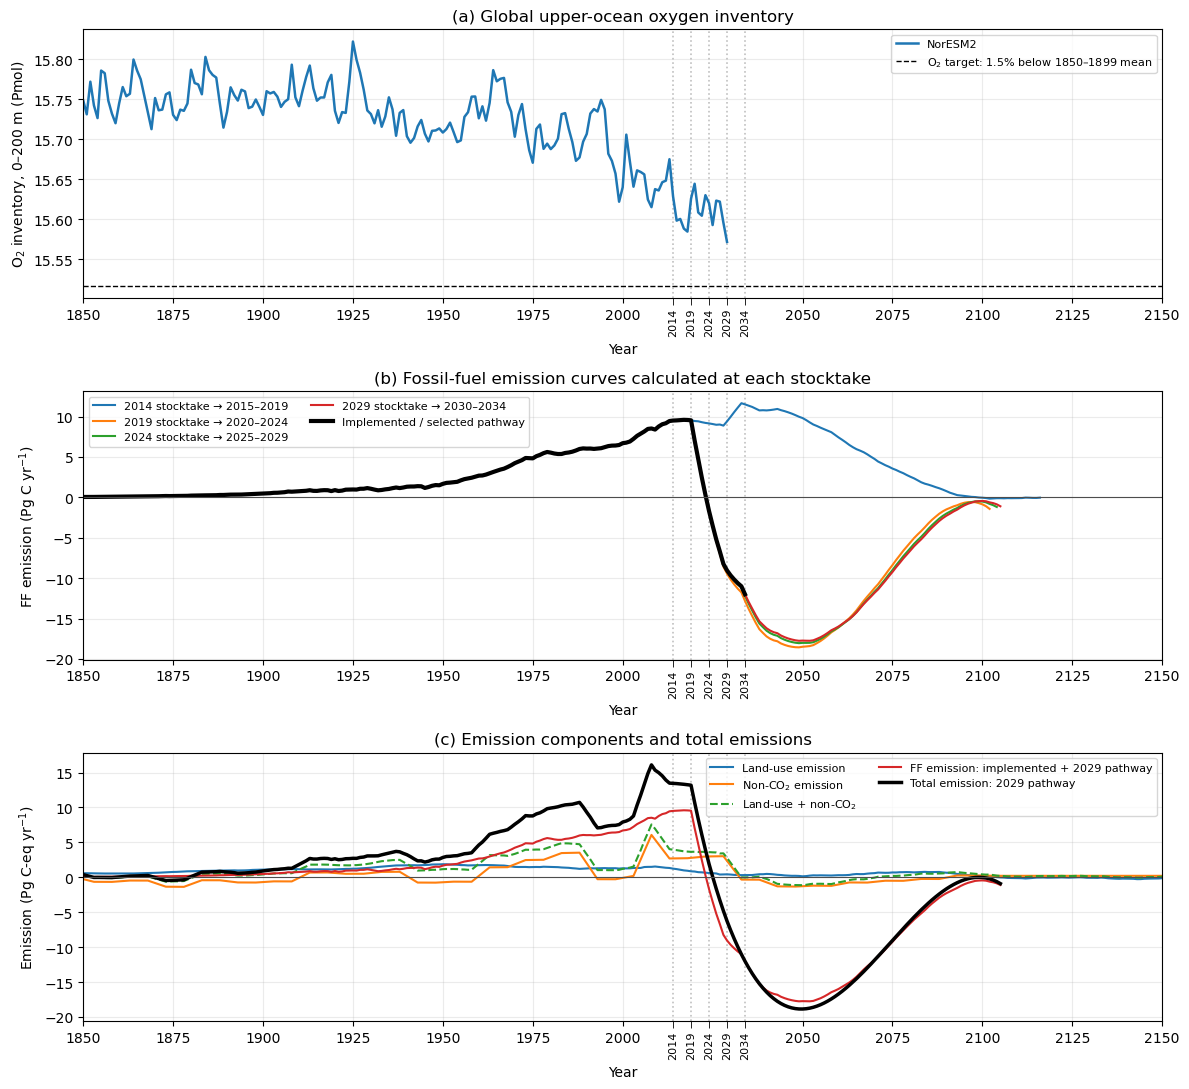

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import aera_oxygen

# ============================================================
# Files
# ============================================================

AERA_ID = "AERA_O2var_0_200m_minus1p5pct"

HIST_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    f"AERA_hist/{AERA_ID}"
)

FUTURE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/AERA_NorESM2/"
    f"AERA_future/{AERA_ID}"
)

STATE_FILE = f"{FUTURE_DIR}/{AERA_ID}_state_2029.csv"

CURVE_FILES = {
    "2014 stocktake → 2015–2019": (
        f"{HIST_DIR}/{AERA_ID}_hist_nird_2014.csv"
    ),
    "2019 stocktake → 2020–2024": (
        f"{FUTURE_DIR}/{AERA_ID}_2019.csv"
    ),
    "2024 stocktake → 2025–2029": (
        f"{FUTURE_DIR}/{AERA_ID}_2024.csv"
    ),
    "2029 stocktake → 2030–2034": (
        f"{FUTURE_DIR}/{AERA_ID}_2029.csv"
    ),
}


# ============================================================
# Readers
# ============================================================

def read_year_csv(path):
    df = pd.read_csv(path)

    year_col = "year" if "year" in df.columns else df.columns[0]
    df = df.rename(columns={year_col: "year"})
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

    return (
        df.dropna(subset=["year"])
        .assign(year=lambda x: x["year"].astype(int))
        .set_index("year")
        .sort_index()
    )


def read_ff_curve(path):
    df = read_year_csv(path)

    if "ff_emission" in df.columns:
        col = "ff_emission"
    else:
        numeric_cols = [
            c for c in df.columns
            if pd.api.types.is_numeric_dtype(df[c])
        ]

        if not numeric_cols:
            raise ValueError(
                f"No numeric emission column found in {path}\n"
                f"Columns: {df.columns.tolist()}"
            )

        col = numeric_cols[0]

    return pd.to_numeric(df[col], errors="coerce").dropna()


# ============================================================
# Load Oxygen state
# ============================================================

state = read_year_csv(STATE_FILE)

o2_col = next(
    c for c in [
        "O2var",
        "o2var",
        "O2",
        "o2_inventory_0_200m",
        "global_o2_inventory_0_200m",
    ]
    if c in state.columns
)

o2_inventory = pd.to_numeric(
    state[o2_col],
    errors="coerce",
).dropna()

ff_state = pd.to_numeric(
    state["ff_emission"],
    errors="coerce",
).dropna()

ff_curves = {
    label: read_ff_curve(path)
    for label, path in CURVE_FILES.items()
}


# ============================================================
# Oxygen target
# ============================================================

O2_SCALE = 1e15  # 1 Pmol = 1e15 mol

# 1850–2014 values are already expressed in Pmol.
# Convert them back to mol so the entire series has consistent units.
o2_inventory_mol = o2_inventory.copy()

o2_inventory_mol.loc[
    o2_inventory_mol.index < 2015
] *= O2_SCALE

# Reference and target calculated consistently in mol
o2_reference = o2_inventory_mol.loc[1850:1899].mean()
o2_target = o2_reference * 0.985

# Convert the full series to Pmol for plotting
o2_inventory_pmol = o2_inventory_mol / O2_SCALE
o2_target_pmol = o2_target / O2_SCALE

print(f"O2 reference, 1850–1899: {o2_reference / O2_SCALE:.4f} Pmol")
print(f"O2 target, -1.5%       : {o2_target_pmol:.4f} Pmol")


# ============================================================
# LU and non-CO2 emissions
# ============================================================

df_base = aera_oxygen.get_base_df()

lu = pd.to_numeric(
    df_base["lu_emission"],
    errors="coerce",
).dropna()

nonco2 = pd.to_numeric(
    df_base["non_co2_emission"],
    errors="coerce",
).dropna()

nonff_total = pd.concat(
    [
        lu.rename("lu_emission"),
        nonco2.rename("non_co2_emission"),
    ],
    axis=1,
).sum(axis=1, min_count=2)


# ============================================================
# Historical FF + 2029 stocktake future FF curve
# ============================================================

ff_2029_curve = ff_curves[
    "2029 stocktake → 2030–2034"
].rename("ff_emission")

ff_2029 = pd.concat(
    [
        ff_state.loc[ff_state.index <= 2029],
        ff_2029_curve.loc[ff_2029_curve.index >= 2030],
    ]
).sort_index()

ff_2029.name = "ff_emission"


# ============================================================
# Total emission based on 2029 stocktake
# ============================================================

emission_2029 = pd.concat(
    [
        ff_2029,
        lu.rename("lu_emission"),
        nonco2.rename("non_co2_emission"),
    ],
    axis=1,
)

emission_2029["total_emission"] = emission_2029[
    ["ff_emission", "lu_emission", "non_co2_emission"]
].sum(axis=1, min_count=3)

total_emission_2029 = emission_2029["total_emission"].dropna()


# ============================================================
# Plot settings
# ============================================================

PLOT_START = 1850
PLOT_END = 2150

STOCKTAKE_YEARS = [2014, 2019, 2024, 2029, 2034]

MAJOR_TICKS = [
    year
    for year in range(PLOT_START, PLOT_END + 1, 25)
    if year != 2025
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 11),
    sharex=True,
)


def format_time_axis(ax):
    ax.set_xlim(PLOT_START, PLOT_END)

    ax.set_xticks(MAJOR_TICKS)

    ax.set_xticks(STOCKTAKE_YEARS, minor=True)
    ax.set_xticklabels(
        [str(year) for year in STOCKTAKE_YEARS],
        minor=True,
        rotation=90,
        fontsize=8,
    )

    ax.grid(which="major", alpha=0.25)

    ax.grid(
        axis="x",
        which="minor",
        linestyle=":",
        linewidth=1.2,
        alpha=0.8,
    )

    ax.tick_params(
        axis="x",
        which="major",
        labelbottom=True,
    )

    ax.tick_params(
        axis="x",
        which="minor",
        labelbottom=True,
        length=5,
        pad=2,
    )

    ax.set_xlabel("Year")


# ============================================================
# Panel 1: O2 inventory
# ============================================================

ax = axes[0]

ax.plot(
    o2_inventory_pmol.index,
    o2_inventory_pmol,
    lw=1.8,
    label="NorESM2",
)

ax.axhline(
    o2_target_pmol,
    color="k",
    linestyle="--",
    linewidth=1,
    label="O$_2$ target: 1.5% below 1850–1899 mean",
)

ax.set_ylabel("O$_2$ inventory, 0–200 m (Pmol)")
ax.set_title("(a) Global upper-ocean oxygen inventory")
ax.legend(fontsize=8)

format_time_axis(ax)


# ============================================================
# Panel 2: FF curves at each stocktake
# ============================================================

ax = axes[1]

for label, curve in ff_curves.items():
    curve_plot = curve.loc[
        (curve.index >= PLOT_START)
        & (curve.index <= PLOT_END)
    ]

    ax.plot(
        curve_plot.index,
        curve_plot,
        lw=1.5,
        label=label,
    )

ff_state_plot = ff_state.loc[
    (ff_state.index >= PLOT_START)
    & (ff_state.index <= PLOT_END)
]

ax.plot(
    ff_state_plot.index,
    ff_state_plot,
    color="k",
    lw=3,
    label="Implemented / selected pathway",
)

ax.axhline(0, color="0.3", lw=0.8)

ax.set_ylabel("FF emission (Pg C yr$^{-1}$)")
ax.set_title(
    "(b) Fossil-fuel emission curves calculated at each stocktake"
)
ax.legend(fontsize=8, ncol=2)

format_time_axis(ax)


# ============================================================
# Panel 3: emission components and total
# ============================================================

ax = axes[2]

ax.plot(
    lu.index,
    lu,
    lw=1.5,
    label="Land-use emission",
)

ax.plot(
    nonco2.index,
    nonco2,
    lw=1.5,
    label="Non-CO$_2$ emission",
)

ax.plot(
    nonff_total.index,
    nonff_total,
    lw=1.5,
    linestyle="--",
    label="Land-use + non-CO$_2$",
)

ax.plot(
    ff_2029.index,
    ff_2029,
    lw=1.5,
    label="FF emission: implemented + 2029 pathway",
)

ax.plot(
    total_emission_2029.index,
    total_emission_2029,
    color="k",
    lw=2.5,
    label="Total emission: 2029 pathway",
)

ax.axhline(0, color="0.3", lw=0.8)

ax.set_ylabel("Emission (Pg C-eq yr$^{-1}$)")
ax.set_title("(c) Emission components and total emissions")
ax.legend(fontsize=8, ncol=2)

format_time_axis(ax)


plt.tight_layout()
plt.show()